# `PowerScheduler`

This notebook provides an empirical demonstration of the expected behavior of a `PowerScheduler`. Its purpose is to make the module's scheduling behavior observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is power scheduling across depth. A `PowerScheduler` changes its value according to a power relationship as depth increases, while respecting the configured lower and upper bounds.

## Conceptual Overview

A `PowerScheduler` defines a power relationship between depth and scheduled value. For a scale $a$, exponent $p$, offset $o$, and intercept $b$, the unconstrained value at depth $d$ is

$$
S(d)=a(d+o)^p+b.
$$

The scale determines the magnitude of the power component, the exponent controls how the scheduled value changes with depth, the offset shifts its input along the depth axis, and the intercept shifts the resulting relationship vertically. The configured minimum and maximum values bound the schedule within the permitted range.

### Scope of the demonstration

The experiment evaluates a `PowerScheduler` over a finite range of depths and visualizes the resulting schedule.

In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.schedulers import PowerScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible, but they should not be interpreted as general-purpose defaults.

`SCALE = 10` defines the magnitude of the power component.

`EXPONENT = 0.5` determines how the scheduled value changes as depth increases.

`OFFSET = 0` leaves the power input aligned with depth.

`INTERCEPT = 0` leaves the power relationship vertically unshifted.

`MIN_VALUE = 0` and `MAX_VALUE = 1000` define the lower and upper bounds of the schedule.

`MAX_DEPTH = 10000` determines the range over which the schedule is visualized. It does not affect the scheduler itself.

In [2]:
# hyperparameters
SCALE = 10
EXPONENT = 0.5
OFFSET = 0
INTERCEPT = 0
MIN_VALUE = 0
MAX_VALUE = 1000

# plot parameters
MAX_DEPTH = 10000

## Visualization Utilities

The `PowerScheduler` can be evaluated directly at a requested depth. The following helper exposes that mapping for visualization.

`plot_scheduler()` evaluates the scheduler at every depth from zero through `MAX_DEPTH` and plots the resulting schedule. This provides a direct view of its behavior across the displayed range.

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: PowerScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (PowerScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Power Scheduler "
        f"(scale={SCALE}, exponent={EXPONENT}, offset={OFFSET}, "
        f"intercept={INTERCEPT}, min_value={MIN_VALUE}, "
        f"max_value={MAX_VALUE})"
    )
    ax.grid(visible=True, alpha=0.3)
    return

## Evaluation

The plot shows the scheduled value increasing from `0` at depth `0` to `1000` at depth `10000`. The increase is initially steep and becomes progressively more gradual as depth grows, reflecting a decreasing rate of change throughout the displayed range.

The curved trajectory confirms that equal increases in depth produce increasingly smaller changes in the scheduled value while the schedule remains within its configured bounds.

In [4]:
# initialize a PowerScheduler
scheduler = PowerScheduler(
    scale=SCALE,
    exponent=EXPONENT,
    offset=OFFSET,
    intercept=INTERCEPT,
    min_value=MIN_VALUE,
    max_value=MAX_VALUE,
)

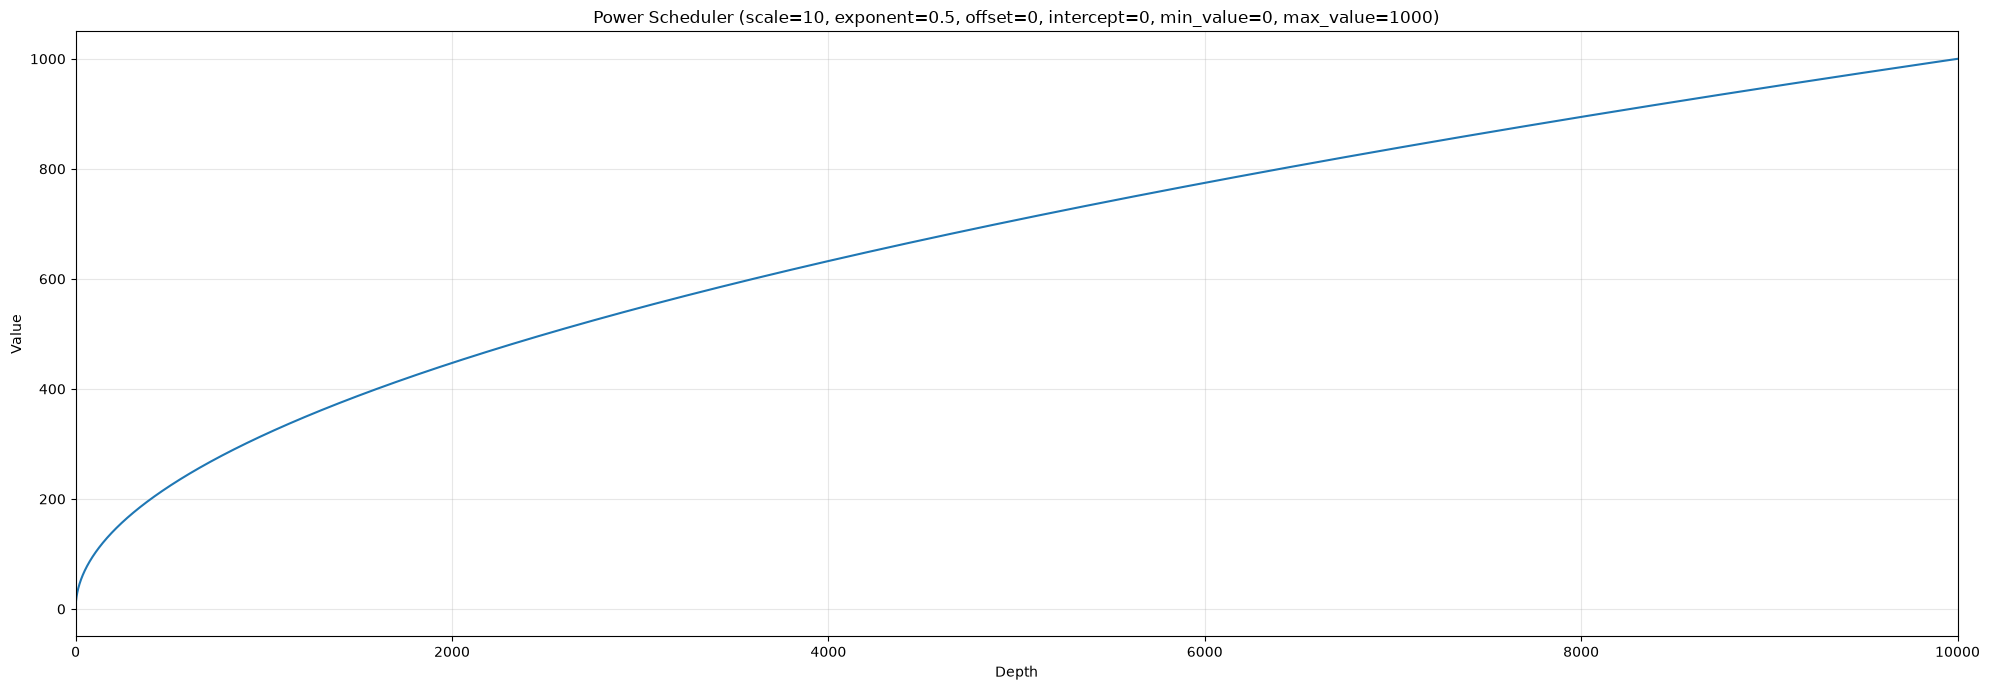

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()

## Conclusions

This playground provides an empirical view of how a `PowerScheduler` maps depth to a value whose rate of change evolves according to the configured exponent. With the configured exponent between zero and one, that rate decreases as depth increases, while the scale, offset, and intercept determine the magnitude and position of the power relationship, and the minimum and maximum values constrain the resulting schedule.

Examined in isolation, the module exhibits its intended behavior: it implements a bounded power scheduling strategy in which the scheduled value grows at a decreasing rate across depth.